# **Model: KNN**

**1. Imports**

In [1]:
import os
import glob
import time
import gc
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


**2. Loading Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving CIC-IDS2017.zip to CIC-IDS2017.zip


**3. Exxtracting Zip**

In [3]:
!mkdir -p /content/CIC-IDS2017
!unzip -q "/content/CIC-IDS2017.zip" -d "/content/CIC-IDS2017"

parquet_files = glob.glob(
    "/content/CIC-IDS2017/**/*.parquet",
    recursive=True
)

print("Found:", len(parquet_files), "Parquet files")

Found: 8 Parquet files


**4. Loading Data**

In [4]:
dataframes = []

for file in parquet_files:
    temp = pd.read_parquet(file)
    print(os.path.basename(file), temp.shape)
    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)

del dataframes
gc.collect()

df.columns = df.columns.str.strip()

print("Combined shape:", df.shape)

Botnet-Friday-no-metadata.parquet (176038, 78)
Portscan-Friday-no-metadata.parquet (119522, 78)
Benign-Monday-no-metadata.parquet (458831, 78)
Infiltration-Thursday-no-metadata.parquet (207630, 78)
DoS-Wednesday-no-metadata.parquet (584991, 78)
WebAttacks-Thursday-no-metadata.parquet (155820, 78)
Bruteforce-Tuesday-no-metadata.parquet (389714, 78)
DDoS-Friday-no-metadata.parquet (221264, 78)
Combined shape: (2313810, 78)


**5. Cleaning** **Data**

In [5]:
print("Before cleaning:", df.shape)

df = df.drop_duplicates().copy()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna().copy()

print("After cleaning:", df.shape)

Before cleaning: (2313810, 78)
After cleaning: (2231806, 78)


In [6]:
df["Label"] = df["Label"].astype(str).str.strip()

df["Target"] = np.where(
    df["Label"].str.upper() == "BENIGN",
    0,
    1
)

X = df.drop(columns=["Label", "Target"])
y = df["Target"]

print("Features:", X.shape[1])
print("\nTarget distribution:")
print(y.value_counts())

Features: 77

Target distribution:
Target
0    1895314
1     336492
Name: count, dtype: int64


**6. Train/Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Full training set:", X_train.shape)
print("Full test set:", X_test.shape)

Full training set: (1785444, 77)
Full test set: (446362, 77)


In [8]:
del df, X, y
gc.collect()

51

**7. KNN Scaling**

In [9]:
scaler = StandardScaler()

start = time.time()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaling completed in {time.time() - start:.2f} seconds")
print(X_train_scaled.shape)
print(X_test_scaled.shape)

Scaling completed in 2.65 seconds
(1785444, 77)
(446362, 77)


**8. Creating a KNN training subset**

In [10]:
X_knn_train, _, y_knn_train, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=200_000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("KNN training subset:", X_knn_train.shape)
print("\nDistribution:")
print(y_knn_train.value_counts())
print(y_knn_train.value_counts(normalize=True) * 100)

KNN training subset: (200000, 77)

Distribution:
Target
0    169846
1     30154
Name: count, dtype: int64
Target
0    84.923
1    15.077
Name: proportion, dtype: float64


In [11]:
X_knn_test, _, y_knn_test, _ = train_test_split(
    X_test_scaled,
    y_test,
    train_size=50_000,
    random_state=RANDOM_STATE,
    stratify=y_test
)

print("KNN test subset:", X_knn_test.shape)
print(y_knn_test.value_counts())

KNN test subset: (50000, 77)
Target
0    42461
1     7539
Name: count, dtype: int64


**9. Train KNN v1**

In [12]:
knn_model_full = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski",
    p=2,
    n_jobs=-1
)

start_time = time.time()

knn_model_full.fit(
    X_train_scaled,
    y_train
)

training_time = time.time() - start_time

print("Full KNN fit complete.")
print(f"Training samples: {len(y_train):,}")
print(f"Fit time: {training_time:.2f} seconds")

Full KNN fit complete.
Training samples: 1,785,444
Fit time: 0.93 seconds


**10. Evaluate KNN v1**

In [13]:
# Test KNN prediction speed on 1,000 samples first

start_time = time.time()

_ = knn_model_full.predict(
    X_test_scaled[:1000]
)

benchmark_time = time.time() - start_time

estimated_full = benchmark_time * (len(X_test_scaled) / 1000)

print(f"1,000 predictions: {benchmark_time:.2f} seconds")
print(f"Estimated full test: {estimated_full:.2f} seconds")
print(f"Estimated full test: {estimated_full/60:.2f} minutes")

1,000 predictions: 28.21 seconds
Estimated full test: 12591.17 seconds
Estimated full test: 209.85 minutes


In [14]:
start_time = time.time()

y_pred_knn_full = knn_model_full.predict(X_test_scaled)

prediction_time = time.time() - start_time

print("Full KNN prediction complete.")
print(f"Test samples: {len(y_test):,}")
print(f"Prediction time: {prediction_time:.2f} seconds")
print(f"Prediction time: {prediction_time/60:.2f} minutes")

Full KNN prediction complete.
Test samples: 446,362
Prediction time: 7645.99 seconds
Prediction time: 127.43 minutes


**11. Full KNN Metrics**

In [15]:
accuracy = accuracy_score(y_test, y_pred_knn_full)
precision = precision_score(y_test, y_pred_knn_full)
recall = recall_score(y_test, y_pred_knn_full)
f1 = f1_score(y_test, y_pred_knn_full)

print("=== Sentinel KNN v1 — FULL DATASET ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn_full,
        target_names=["BENIGN", "ATTACK"],
        digits=6
    )
)

=== Sentinel KNN v1 — FULL DATASET ===
Accuracy : 0.998273
Precision: 0.995118
Recall   : 0.993417
F1 Score : 0.994267

Classification Report:
              precision    recall  f1-score   support

      BENIGN   0.998832  0.999135  0.998983    379063
      ATTACK   0.995118  0.993417  0.994267     67299

    accuracy                       0.998273    446362
   macro avg   0.996975  0.996276  0.996625    446362
weighted avg   0.998272  0.998273  0.998272    446362



**12. Confusion Matrix**

True Negatives : 378735
False Positives: 328
False Negatives: 443
True Positives : 66856

False Positive Rate: 0.000865
False Negative Rate: 0.006583


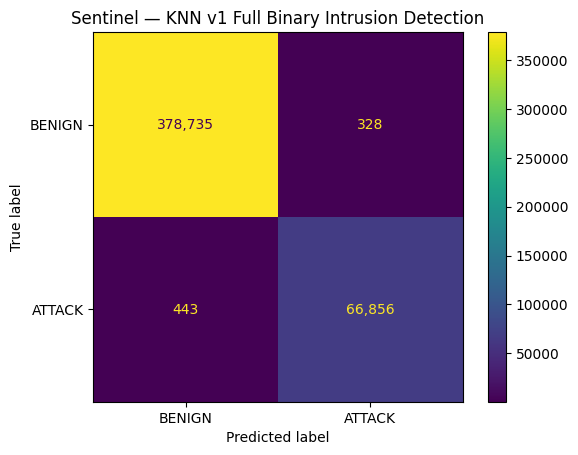

In [16]:
cm_knn_full = confusion_matrix(y_test, y_pred_knn_full)

tn, fp, fn, tp = cm_knn_full.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print(f"\nFalse Positive Rate: {fp/(fp+tn):.6f}")
print(f"False Negative Rate: {fn/(fn+tp):.6f}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_full,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format=",")
plt.title("Sentinel — KNN v1 Full Binary Intrusion Detection")
plt.show()

**13. Evaluation in Dataframes**

In [18]:
knn_confusion_df = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=["Actual BENIGN", "Actual ATTACK"],
    columns=["Predicted BENIGN", "Predicted ATTACK"]
)

knn_confusion_df

,Predicted BENIGN,Predicted ATTACK
Actual BENIGN,378735,328
Actual ATTACK,443,66856


In [19]:
knn_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_knn_full,
        target_names=["BENIGN", "ATTACK"],
        output_dict=True
    )
).transpose()

knn_report_df

,precision,recall,f1-score,support
BENIGN,0.998832,0.999135,0.998983,379063.000000
ATTACK,0.995118,0.993417,0.994267,67299.000000
accuracy,0.998273,0.998273,0.998273,0.998273
macro avg,0.996975,0.996276,0.996625,446362.000000
weighted avg,0.998272,0.998273,0.998272,446362.000000


**14. Saving Model**

In [20]:
print("X_train type:", type(X_train))
print("X_train shape:", X_train.shape)

if hasattr(X_train, "columns"):
    print("Number of columns:", len(X_train.columns))
    print(list(X_train.columns))

X_train type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (1785444, 77)
Number of columns: 77
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count'

In [21]:
import joblib

# Save trained KNN model
joblib.dump(
    knn_model_full,
    "/content/sentinel_knn_binary_v1.joblib"
)

# Save fitted StandardScaler
joblib.dump(
    scaler,
    "/content/sentinel_knn_scaler_v1.joblib"
)

# Save exact feature order
feature_columns = list(X_train.columns)

joblib.dump(
    feature_columns,
    "/content/sentinel_feature_columns_v1.joblib"
)

print("All KNN artifacts saved.")

All KNN artifacts saved.


In [22]:
import os

files_to_check = [
    "/content/sentinel_knn_binary_v1.joblib",
    "/content/sentinel_knn_scaler_v1.joblib",
    "/content/sentinel_feature_columns_v1.joblib"
]

for f in files_to_check:
    print(f"{os.path.basename(f)}: {os.path.getsize(f)/(1024**2):.2f} MB")

sentinel_knn_binary_v1.joblib: 1062.51 MB
sentinel_knn_scaler_v1.joblib: 0.00 MB
sentinel_feature_columns_v1.joblib: 0.00 MB
